# 13 — Symbolic DQN: Train on World 1-1

Trains a DQN agent on **World 1-1** using the RAM-based symbolic grid (13×16).

**Setup:**
- Observation: flattened 13×16 grid × 4 frame-stack = **832-dim** vector
- Policy: `MlpPolicy` with default net arch
- 8 parallel envs, 2M steps
- TensorBoard logging for metric tracking
- Saves to `models/symbolic_dqn_w1l1/`

In [1]:
# --- Google Colab Setup ---
import os, sys

if os.getenv('COLAB_RELEASE_TAG'):
    !pip install -q Cython setuptools wheel
    !git clone -b hotfix/version1 https://github.com/lmartim4/CSC-52081-ContinousMountainCar.git /content/repo
    %cd /content/repo
    !pip install -r requirements.txt --no-build-isolation
    sys.path.insert(0, '/content/repo')
    import site; SITE = site.getsitepackages()[0]
    !patch --forward -p0 {SITE}/nes_py/_rom.py                   < patches/nes_py_numpy2.patch || true
    !patch --forward -p0 {SITE}/gym/utils/passive_env_checker.py < patches/gym_bool8_numpy2.patch || true
    !patch --forward -p0 {SITE}/gym_super_mario_bros/smb_env.py  < patches/smb_env_numpy2.patch || true
    !sed -i 's/observation, reward, terminated, truncated, info = self.env.step(action)/_result = self.env.step(action); observation, reward, terminated, info = _result[:4]; truncated = _result[4] if len(_result) > 4 else False/' {SITE}/gym/wrappers/time_limit.py
    !git pull
else:
    if os.path.basename(os.getcwd()) == 'notebooks':
        %cd ..

/home/contente/Documents/ENSTA/autonomous/CSC-52081-ContinousMountainCar


In [2]:
import torch
from stable_baselines3 import DQN

from src.wrappers import make_symbolic_vec_env, make_symbolic_env
from src.utils.callbacks import CheckpointAndLogCallback
from src.config import DQNConfig

print(f'Using CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using CUDA: True
GPU: NVIDIA GeForce GTX 1650


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
# Create 8 parallel symbolic environments for World 1-1
NUM_ENVS = 8

env = make_symbolic_vec_env(
    env_id='SuperMarioBros-1-1-v3',
    skip=4,
    n_stack=4,
    flatten=True,
    num_envs=NUM_ENVS,
)
print(f'Observation space: {env.observation_space.shape}')
print(f'Action space: {env.action_space.n}')
print(f'Parallel envs: {NUM_ENVS}')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Observation space: (833,)
Action space: 7
Parallel envs: 8


/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. 

In [4]:
# Configure DQN with symbolic (MlpPolicy) settings
LOG_DIR = 'logs/symbolic_dqn_w1l1'
SAVE_DIR = 'models/symbolic_dqn_w1l1'

config = DQNConfig(
    policy='MlpPolicy',
    total_timesteps=2_000_000,
)

model = DQN(
    policy=config.policy,
    env=env,
    learning_rate=config.learning_rate,
    buffer_size=config.buffer_size,
    learning_starts=config.learning_starts,
    batch_size=config.batch_size,
    gamma=config.gamma,
    target_update_interval=config.target_update_interval,
    exploration_fraction=config.exploration_fraction,
    exploration_initial_eps=config.exploration_initial_eps,
    exploration_final_eps=config.exploration_final_eps,
    train_freq=config.train_freq,
    tensorboard_log=LOG_DIR,
    verbose=1,
    device='cpu',  # MLP is faster on CPU
)

print(f'Total timesteps: {config.total_timesteps:,}')
print(f'Device: {model.device}')
print(f'Buffer size: {config.buffer_size:,}')
print(f'Learning starts: {config.learning_starts:,}')

Using cpu device
Total timesteps: 2,000,000
Device: cpu
Buffer size: 100,000
Learning starts: 10,000


In [5]:
# Launch TensorBoard (Colab inline)
%load_ext tensorboard
%tensorboard --logdir {LOG_DIR}

In [6]:
# Train for 2M steps
callback = CheckpointAndLogCallback(
    save_path=SAVE_DIR,
    save_freq=50_000,
)

model.learn(
    total_timesteps=config.total_timesteps,
    callback=callback,
    log_interval=10,
)
model.save(f'{SAVE_DIR}/final_model')
print('Training complete — final_model saved!')

Logging to logs/symbolic_dqn_w1l1/DQN_1


/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional infor

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 203      |
|    ep_rew_mean      | 37.5     |
|    exploration_rate | 0.964    |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 10       |
|    fps              | 677      |
|    time_elapsed     | 11       |
|    total_timesteps  | 8000     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 463      |
|    ep_rew_mean      | 48.3     |
|    exploration_rate | 0.917    |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 20       |
|    fps              | 631      |
|    time_elapsed     | 29       |
|    total_timesteps  | 18400    |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.00447  |
|    n_updates        | 350      |
----------------------------------
--------------------

/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym_super_mario_bros/smb_env.py:177: RuntimeWarning: overflow encountered in scalar add
  return 255 + (255 - self._y_pixel)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 152      |
|    ep_rew_mean      | 68.8     |
|    exploration_rate | 0.1      |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 1680     |
|    fps              | 557      |
|    time_elapsed     | 583      |
|    total_timesteps  | 325536   |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.579    |
|    n_updates        | 13147    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 157      |
|    ep_rew_mean      | 70.8     |
|    exploration_rate | 0.1      |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 1690     |
|    fps              | 557      |
|    time_elapsed     | 587      |
|    total_timesteps  | 327680   |
| train/              |          |
|    learning_rate  

...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 97.2     |
|    ep_rew_mean      | 46.8     |
|    exploration_rate | 0.1      |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 4840     |
|    fps              | 538      |
|    time_elapsed     | 1257     |
|    total_timesteps  | 677792   |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.148    |
|    n_updates        | 27825    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 95.7     |
|    ep_rew_mean      | 46       |
|    exploration_rate | 0.1      |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 4850     |
|    fps              | 538      |
|    time_elapsed     | 1259     |
|    total_timesteps  | 678744   |
| train/              |          |
|    learning_rate  

/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym_super_mario_bros/smb_env.py:177: RuntimeWarning: overflow encountered in scalar add
  return 255 + (255 - self._y_pixel)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 96.8     |
|    ep_rew_mean      | 49.8     |
|    exploration_rate | 0.1      |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 5520     |
|    fps              | 537      |
|    time_elapsed     | 1382     |
|    total_timesteps  | 743512   |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.216    |
|    n_updates        | 30563    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 97.2     |
|    ep_rew_mean      | 49.8     |
|    exploration_rate | 0.1      |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 5530     |
|    fps              | 537      |
|    time_elapsed     | 1384     |
|    total_timesteps  | 744328   |
| train/              |          |
|    learning_rate  

/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym_super_mario_bros/smb_env.py:177: RuntimeWarning: overflow encountered in scalar add
  return 255 + (255 - self._y_pixel)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 96.1     |
|    ep_rew_mean      | 50.7     |
|    exploration_rate | 0.1      |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 7170     |
|    fps              | 535      |
|    time_elapsed     | 1708     |
|    total_timesteps  | 914792   |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.136    |
|    n_updates        | 37700    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 101      |
|    ep_rew_mean      | 52.4     |
|    exploration_rate | 0.1      |
|    flag_rate_100    | 0        |
| time/               |          |
|    episodes         | 7180     |
|    fps              | 535      |
|    time_elapsed     | 1709     |
|    total_timesteps  | 915480   |
| train/              |          |
|    learning_rate  

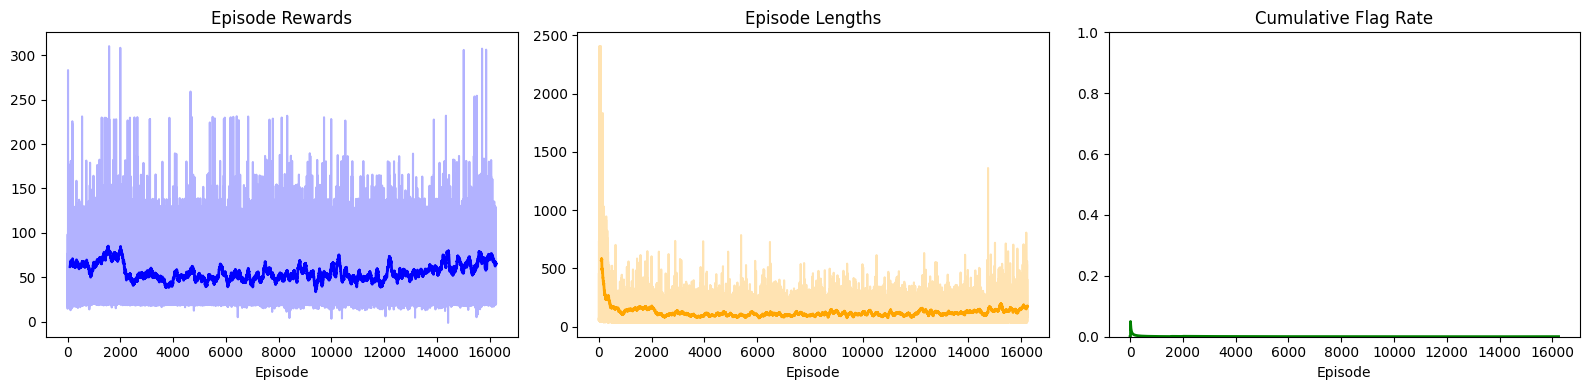

In [7]:
# Plot training curves from callback
import matplotlib.pyplot as plt
import numpy as np

all_rewards = callback.episode_rewards
all_lengths = callback.episode_lengths
all_flags   = callback.episode_flags

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
window = min(100, len(all_rewards))

for ax, data, color, title in zip(
    axes,
    [all_rewards, all_lengths, None],
    ['blue', 'orange', 'green'],
    ['Episode Rewards', 'Episode Lengths', 'Cumulative Flag Rate'],
):
    if title == 'Cumulative Flag Rate':
        if all_flags:
            cum = np.cumsum(all_flags) / (np.arange(len(all_flags)) + 1)
            ax.plot(cum, color=color, linewidth=2)
            ax.set_ylim(0, 1)
    else:
        ax.plot(data, alpha=0.3, color=color)
        if len(data) > window:
            smoothed = np.convolve(data, np.ones(window) / window, mode='valid')
            ax.plot(range(window - 1, len(data)), smoothed, color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Episode')

plt.tight_layout()
os.makedirs(SAVE_DIR, exist_ok=True)
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=150)
plt.show()

Found 1 TensorBoard event file(s)

Available scalar tags:
  - rollout/ep_len_mean
  - rollout/ep_rew_mean
  - rollout/exploration_rate
  - rollout/flag_rate_100
  - time/fps
  - train/learning_rate
  - train/loss


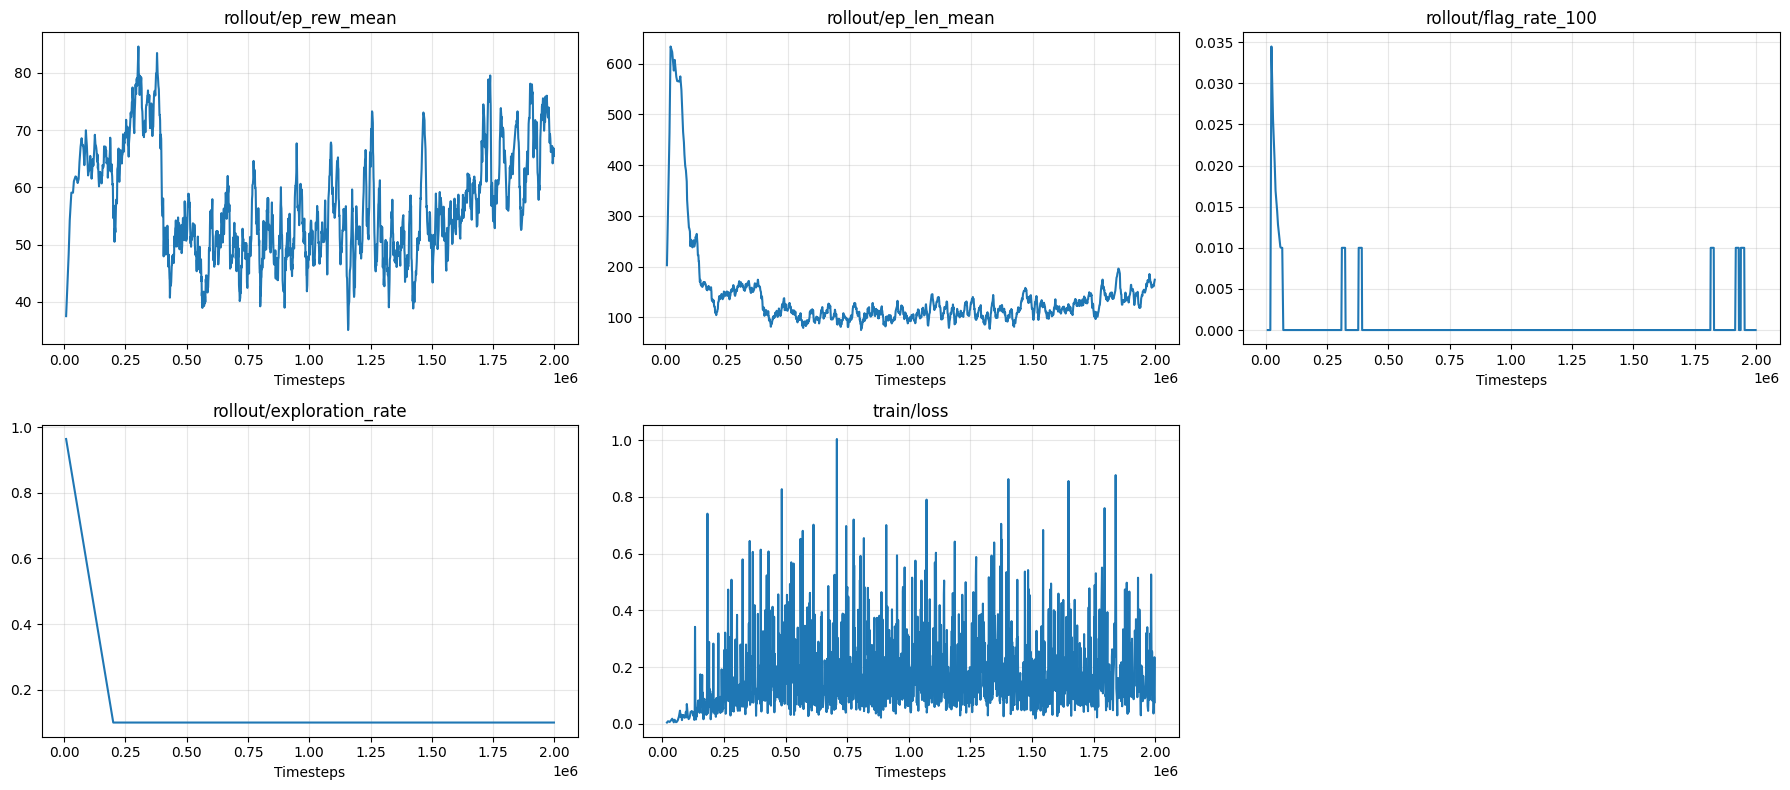

In [8]:
# Retrieve TensorBoard metrics programmatically
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import glob

event_files = sorted(glob.glob(f'{LOG_DIR}/**/events.out.tfevents.*', recursive=True))
print(f'Found {len(event_files)} TensorBoard event file(s)')

if event_files:
    ea = EventAccumulator(os.path.dirname(event_files[-1]))
    ea.Reload()

    print('\nAvailable scalar tags:')
    for tag in ea.Tags()['scalars']:
        print(f'  - {tag}')

    metrics = {}
    for tag in ea.Tags()['scalars']:
        events = ea.Scalars(tag)
        metrics[tag] = {
            'steps': [e.step for e in events],
            'values': [e.value for e in events],
        }

    tb_keys = [
        'rollout/ep_rew_mean',
        'rollout/ep_len_mean',
        'rollout/flag_rate_100',
        'rollout/exploration_rate',
        'train/loss',
        'train/n_updates',
    ]
    available_keys = [k for k in tb_keys if k in metrics]

    if available_keys:
        n_plots = len(available_keys)
        cols = min(3, n_plots)
        rows = (n_plots + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
        if n_plots == 1:
            axes = [axes]
        else:
            axes = np.array(axes).flatten()

        for ax, key in zip(axes, available_keys):
            ax.plot(metrics[key]['steps'], metrics[key]['values'], linewidth=1.5)
            ax.set_title(key)
            ax.set_xlabel('Timesteps')
            ax.grid(True, alpha=0.3)

        for ax in axes[len(available_keys):]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.savefig(f'{SAVE_DIR}/tensorboard_metrics.png', dpi=150)
        plt.show()
    else:
        print('No matching scalar tags found.')

In [9]:
# Evaluate final model — 10 episodes
import numpy as np
from stable_baselines3 import DQN

eval_model = DQN.load(f'{SAVE_DIR}/final_model')

eval_env = make_symbolic_env(
    env_id='SuperMarioBros-1-1-v3',
    skip=4, n_stack=4, flatten=True,
)

rewards, lengths, flags = [], [], []

for ep in range(10):
    reset_result = eval_env.reset()
    obs = reset_result[0] if isinstance(reset_result, tuple) else reset_result
    done, total_reward, steps, flag = False, 0.0, 0, False

    while not done:
        action, _ = eval_model.predict(obs, deterministic=True)
        result = eval_env.step(int(action))
        if len(result) == 5:
            obs, reward, terminated, truncated, info = result
            done = terminated or truncated
        else:
            obs, reward, done, info = result
        total_reward += float(reward)
        steps += 1
        if isinstance(info, dict) and info.get('flag_get', False):
            flag = True

    rewards.append(total_reward)
    lengths.append(steps)
    flags.append(flag)
    print(f'Episode {ep+1:2d}: reward={total_reward:.1f}, steps={steps}, {"FLAG!" if flag else "DEAD"}')

print(f'\nMean reward: {np.mean(rewards):.1f} \u00b1 {np.std(rewards):.1f}')
print(f'Mean length: {np.mean(lengths):.0f}')
print(f'Flag rate:   {np.mean(flags):.0%}')

eval_env.close()

/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(


Episode  1: reward=55.3, steps=82, DEAD
Episode  2: reward=55.3, steps=82, DEAD
Episode  3: reward=55.3, steps=82, DEAD
Episode  4: reward=55.3, steps=82, DEAD
Episode  5: reward=55.3, steps=82, DEAD
Episode  6: reward=55.3, steps=82, DEAD
Episode  7: reward=55.3, steps=82, DEAD
Episode  8: reward=55.3, steps=82, DEAD
Episode  9: reward=55.3, steps=82, DEAD
Episode 10: reward=55.3, steps=82, DEAD

Mean reward: 55.3 ± 0.0
Mean length: 82
Flag rate:   0%


In [10]:
# Download model from Colab (optional)
if os.getenv('COLAB_RELEASE_TAG'):
    from google.colab import files
    import shutil
    shutil.make_archive('symbolic_dqn_w1l1', 'zip', SAVE_DIR)
    files.download('symbolic_dqn_w1l1.zip')
    print('Model archive downloaded!')